In [1]:
import sys
sys.path.append('../../../')

In [2]:
from CADETProcess.processModel import ComponentSystem
from CADETProcess.processModel import Linear
from CADETProcess.processModel import Inlet, LumpedRateModelWithPores, Outlet

# Component System
component_system = ComponentSystem(['A', 'B'])

# Binding Model
binding_model = Linear(component_system)
binding_model.is_kinetic = True
binding_model.adsorption_rate = [2, 3]
binding_model.desorption_rate = [1, 1]

# Column
column = LumpedRateModelWithPores(component_system, name='column')
column.binding_model = binding_model

column.length = 0.6
column.diameter = 0.025
column.bed_porosity = 0.4

column.particle_porosity = 0.7
column.particle_radius = 5.0e-6
column.film_diffusion = component_system.n_comp*[1e-5]

column.axial_dispersion = 1e-8

In [3]:
eluent = Inlet(component_system, name='eluent')
eluent.c = [0, 0]
eluent.flow_rate = 7e-7

feed = Inlet(component_system, name='feed')
feed.c = [10, 10]
feed.flow_rate = 4e-7

extract = Outlet(component_system, name='extract')
raffinate = Outlet(component_system, name='raffinate')

In [4]:
from CADETProcess.modelBuilder import SerialZone, ParallelZone

zone_I = SerialZone(component_system, 'zone_I', 1)
zone_II = SerialZone(component_system, 'zone_II', 1)
zone_III = SerialZone(component_system, 'zone_III', 1)
zone_IV = SerialZone(component_system, 'zone_IV', 1)

In [5]:
from CADETProcess.modelBuilder import CarouselBuilder

builder = CarouselBuilder(component_system, 'smb')
builder.column = column
builder.add_unit(eluent)
builder.add_unit(feed)

builder.add_unit(extract)
builder.add_unit(raffinate)

builder.add_unit(zone_I)
builder.add_unit(zone_II)
builder.add_unit(zone_III)
builder.add_unit(zone_IV)

In [6]:
builder.add_connection(eluent, zone_I)

builder.add_connection(zone_I, extract)
builder.add_connection(zone_I, zone_II)
w_e = 0.14
builder.set_output_state(zone_I, [w_e, 1-w_e])

builder.add_connection(zone_II, zone_III)

builder.add_connection(feed, zone_III)

builder.add_connection(zone_III, raffinate)
builder.add_connection(zone_III, zone_IV)
w_r = 0.13
builder.set_output_state(zone_III, [w_r, 1-w_r])

builder.add_connection(zone_IV, zone_I)

In [7]:
builder.switch_time = 100
process = builder.build_process()

In [8]:
from CADETProcess.simulator import Cadet

process_simulator = Cadet()
# process_simulator.evaluate_stationarity = True
process_simulator.n_cycles = 3

simulation_results = process_simulator.simulate(process)

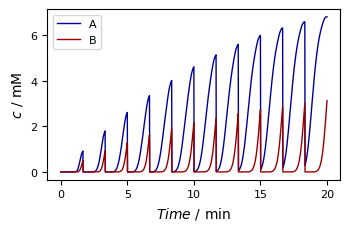

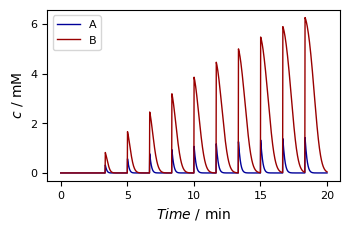

In [9]:
_ = simulation_results.solution.raffinate.inlet.plot()
_ = simulation_results.solution.extract.inlet.plot()

In [10]:
_ = simulation_results.solution.zone_III_inlet.outlet.plot()

In [11]:
from CADETProcess.processModel import Inlet, Outlet
i_wash = Inlet(component_system, name='i_wash')
i_wash.c = [0, 0]
i_wash.flow_rate = 60/60/1e6
i_feed = Inlet(component_system, name='i_feed')
i_feed.c = [10, 10]
i_feed.flow_rate = 30/60/1e6
i_elute = Inlet(component_system, name='i_elute')
i_elute.c = [0, 0]
i_elute.flow_rate = 60/60/1e6

o_waste = Outlet(component_system, name='o_waste')
o_product = Outlet(component_system, name='o_product')

In [12]:
from CADETProcess.modelBuilder import SerialZone, ParallelZone

z_wash = SerialZone(component_system, 'z_wash', 3)
z_feed = ParallelZone(component_system, 'z_feed', 3)
z_dilute = SerialZone(component_system, 'z_dilute', 2, flow_direction=-1)
z_elute = SerialZone(component_system, 'z_elute', 2)

In [13]:
from CADETProcess.modelBuilder import CarouselBuilder

builder = CarouselBuilder(component_system, 'multi_zone')
builder.column = column
builder.add_unit(i_wash)
builder.add_unit(i_feed)
builder.add_unit(i_elute)

builder.add_unit(o_waste)
builder.add_unit(o_product)

builder.add_unit(z_wash)
builder.add_unit(z_feed)
builder.add_unit(z_dilute)
builder.add_unit(z_elute)

builder.add_connection(i_wash, z_wash)
builder.add_connection(z_wash, z_dilute)
builder.add_connection(i_feed, z_feed)
builder.add_connection(z_feed, z_dilute)
builder.add_connection(z_dilute, o_waste)
builder.add_connection(z_dilute, z_elute)
builder.set_output_state(z_dilute, [0.5, 0.5])
builder.add_connection(i_elute, z_elute)
builder.add_connection(z_elute, o_product)